In [7]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

"""
PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)"""


PKLs = []
PKL_titles = []
DIR = "./output_low_memory_10000_09/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
my_dims = np.concatenate([np.arange(1, 11, 1), [20, 50]])
my_dims = np.concatenate([np.arange(1, 11, 1), [20]])
my_dims = np.array([50, 100])
my_dims = np.array([1, 2, 3, 5, 10, 20, 35, 50, 75])

idx_per_dim = {}
for dim in my_dims:
    idx_per_dim[dim] = [idx for idx in range(n) if PKLs[idx]['config']['dim'] == dim]
temperatures = {}
parameters = {}
critical_temperatures = []
for i, dim in enumerate(my_dims):
    temperatures[dim] = np.array([PKLs[idx]['res'][6] for idx in idx_per_dim[dim]]) 
    parameters[dim] = np.array([PKLs[idx]['res'][3].squeeze(axis=-1) for idx in idx_per_dim[dim]])

In [3]:
def last_zero(x):
    return np.where(np.cumsum(x)==0.)[0][-1] if np.any(np.where(np.cumsum(x)==0.)[0]) else None

In [4]:
critical_temperatures = np.zeros(shape=(len(my_dims), len(parameters[50])))
for idxdim, dim in enumerate(parameters.keys()):
    number_of_runs = len(parameters[dim])
    if number_of_runs:
        critical_temperatures[idxdim] = np.array([temperatures[dim][r,0][last_zero(parameters[dim][r,0])] for r in range(number_of_runs)])

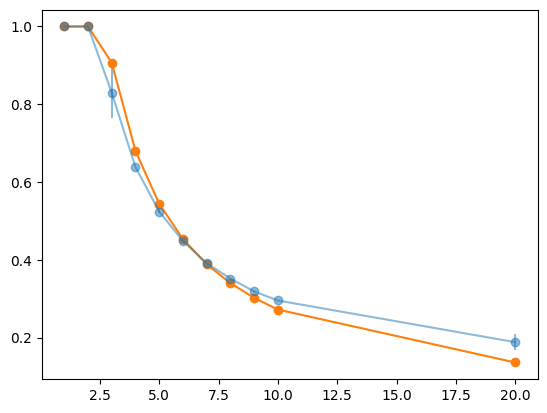

In [25]:
plt.errorbar(my_dims, critical_temperatures.mean(axis=-1), yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.plot(my_dims, np.minimum(1, 2.72 / my_dims), marker='o', label='Critical Temperature')

In [11]:
to_remove_dims = [100]
for d in to_remove_dims:
    for idx in idx_per_dim[d]:
        os.remove(DIR+PKL_titles[idx])

        

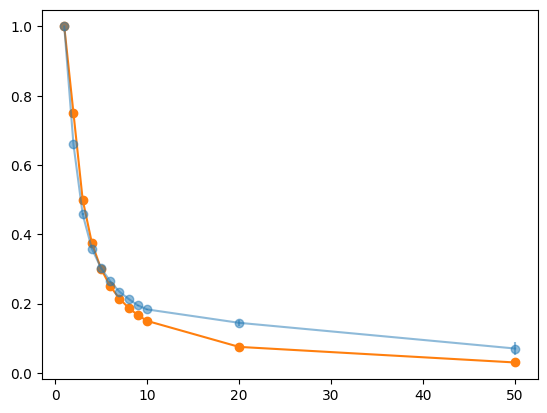

In [7]:
#low memory sample, 1000, 100
plt.errorbar(my_dims, critical_temperatures.mean(axis=-1), yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.plot(my_dims, np.minimum(1, 1.5 / my_dims), marker='o', label='Critical Temperature')

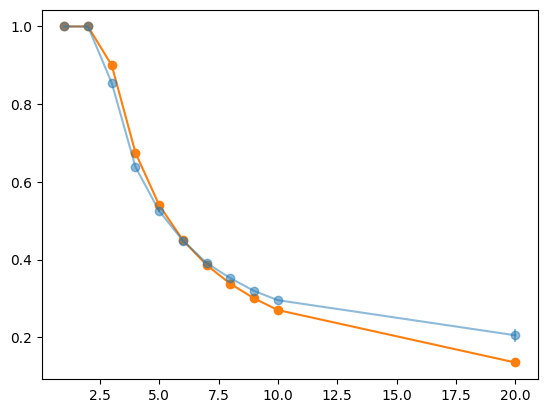

In [32]:
#low memory sample, 10000, 100
my_dims = np.concatenate([np.arange(1, 11, 1), [20]])

plt.errorbar(my_dims, critical_temperatures.mean(axis=-1), yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.plot(my_dims, np.minimum(1, 2.7 / my_dims), marker='o', label='Critical Temperature')

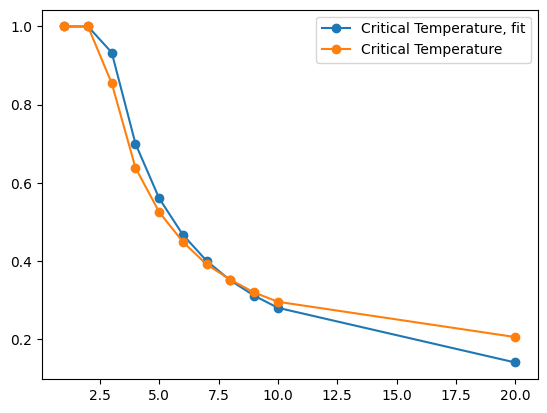

In [100]:
plt.plot(my_dims, np.minimum(1, 2.8 / my_dims), marker='o', label='Critical Temperature, fit')
plt.plot(my_dims, critical_temperatures.mean(axis=-1), marker='o', label='Critical Temperature')
plt.legend()

/tmp/ipykernel_145031/2199541367.py:2: RuntimeWarning: Mean of empty slice.
  plt.errorbar(my_dims, critical_temperatures.mean(axis=-1),critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature')
/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


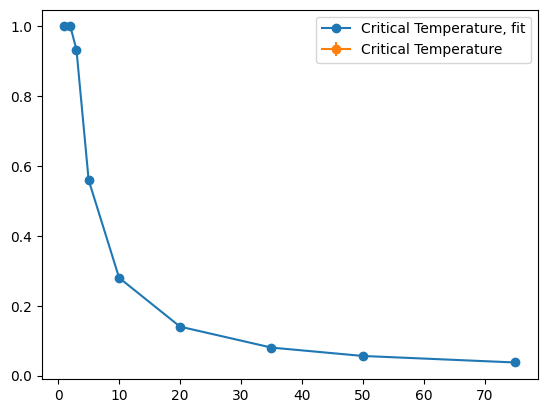

In [5]:
plt.plot(my_dims, np.minimum(1, 2.8 / my_dims), marker='o', label='Critical Temperature, fit')
plt.errorbar(my_dims, critical_temperatures.mean(axis=-1),critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature')
plt.legend()

In [6]:
critical_temperatures

array([], shape=(9, 0), dtype=float64)